## Me trying to break into SEACells to see where the SNN messes up the whole thing

## Preprocessing

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import SEACells
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad

In [2]:
sc_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/sc_data.h5ad")
st_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/st_data.h5ad")
cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)
print("Shape of combined_cell_types", combined_cell_types.shape)
envi_latent_st = st_ad.obsm['envi_latent']
envi_latent_sc = sc_ad.obsm['envi_latent']

print(f"st_ad envi_latent shape: {envi_latent_st.shape}")
print(f"sc_ad envi_latent shape: {envi_latent_sc.shape}")
combined_envi_latent = np.concatenate([envi_latent_sc, envi_latent_st], axis=0)
print(combined_envi_latent.shape)
from sklearn.decomposition import PCA
n_components = 50

pca = PCA(n_components=n_components)
envi_pca = pca.fit_transform(combined_envi_latent)
print("Reduced shape:", envi_pca.shape)

Shape of combined_cell_types (25932,)
st_ad envi_latent shape: (18516, 512)
sc_ad envi_latent shape: (7416, 512)
(25932, 512)
Reduced shape: (25932, 50)


In [3]:
# Flatten the (64, 64) matrices into 1D vectors
st_covet_sqrt_flat = st_ad.obsm["COVET_SQRT"].reshape(st_ad.shape[0], -1)
sc_covet_sqrt_flat = sc_ad.obsm["COVET_SQRT"].reshape(sc_ad.shape[0], -1)

covet_sqrt_combined = np.concatenate([st_covet_sqrt_flat, sc_covet_sqrt_flat], axis=0)
print("Shape after flattening: ", covet_sqrt_combined.shape)
covet_pca = pca.fit_transform(covet_sqrt_combined)
print("Reduced shape:", covet_pca.shape)

Shape after flattening:  (25932, 4096)
Reduced shape: (25932, 50)


In [4]:
combined_matrix=np.concatenate([covet_pca, envi_pca], axis=1)
print(combined_matrix.shape)

(25932, 100)


In [5]:
adata=ad.AnnData(X=combined_matrix)
adata.obs["cell_type"] = combined_cell_types
adata.obsm["combined_matrix"] = combined_matrix
print(adata)

AnnData object with n_obs × n_vars = 25932 × 100
    obs: 'cell_type'
    obsm: 'combined_matrix'


         Falling back to preprocessing with `sc.pp.pca` and default params.


/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


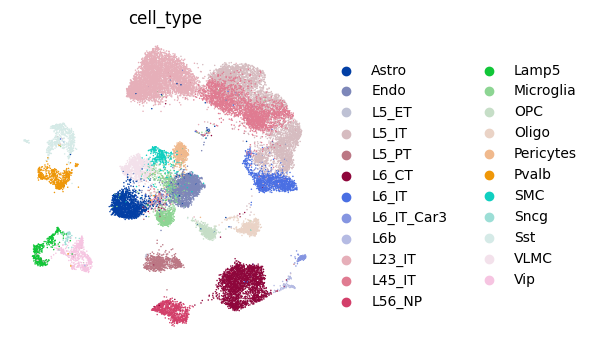

In [6]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cell_type'], frameon=False)

## Loading snn after averaging matrix

In [7]:
from scipy import sparse

snn_after_average = sparse.load_npz("/Users/anushka/Documents/Undergraduate-Project/Approaches/snn_after_average.npz")

In [8]:
snn_after_average

<25932x25932 sparse matrix of type '<class 'numpy.float64'>'
	with 6173570 stored elements in Compressed Sparse Row format>

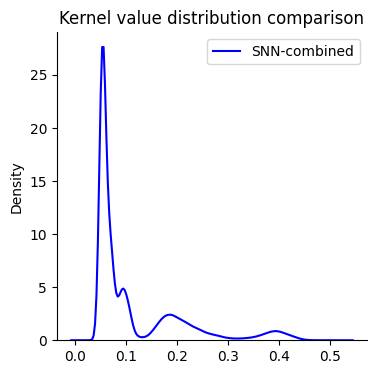

In [9]:
sns.kdeplot(snn_after_average.data, label="SNN-combined", color="blue")
plt.legend()
plt.title("Kernel value distribution comparison")
plt.show()

## Using SEACells

In [10]:
import SEACells
#Construct kernel matrix

n_SEACells=100 
build_kernel_on='X_pca'
n_waypoint_eigs=10

In [11]:
model= SEACells.core.SEACells(adata, 
                              build_kernel_on= build_kernel_on,
                              n_SEACells=n_SEACells,
                              convergence_epsilon=1e-5
                              )

Welcome to SEACells!


In [12]:
adata

AnnData object with n_obs × n_vars = 25932 × 100
    obs: 'cell_type'
    uns: 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'combined_matrix', 'X_pca', 'X_umap'
    obsp: 'distances', 'connectivities'

In [16]:
adata.obsp["snn_graph"] = snn_after_average

In [17]:
adata

AnnData object with n_obs × n_vars = 25932 × 100
    obs: 'cell_type'
    uns: 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'combined_matrix', 'X_pca', 'X_umap'
    obsp: 'distances', 'connectivities', 'snn', 'snn_graph'

In [18]:
model.construct_kernel_matrix_updated()

using your code
Using the updated snn_kernel to calculate this 
Welcome to normalized SNN kernel!
Converting to CSR format...


In [20]:
M=model.kernel_matrix
print(M)

  (0, 0)	1.0
  (0, 18)	0.09906657040119171
  (0, 60)	0.09663116931915283
  (0, 73)	0.21038475632667542
  (0, 142)	0.08760883659124374
  (0, 194)	0.20779947936534882
  (0, 206)	0.09436959773302078
  (0, 241)	0.22721414268016815
  (0, 400)	0.09670013934373856
  (0, 436)	0.09941519051790237
  (0, 511)	0.09484715014696121
  (0, 521)	0.11240070313215256
  (0, 557)	0.10198401659727097
  (0, 583)	0.09765375405550003
  (0, 585)	0.2190256267786026
  (0, 597)	0.10455987602472305
  (0, 631)	0.10071159154176712
  (0, 671)	0.10041891783475876
  (0, 753)	0.09849533438682556
  (0, 805)	0.09906871616840363
  (0, 854)	0.09092631191015244
  (0, 1084)	0.2113678753376007
  (0, 1097)	0.1182468831539154
  (0, 1139)	0.09952203929424286
  (0, 1149)	0.2223842740058899
  :	:
  (25931, 24445)	0.056902412325143814
  (25931, 24542)	0.37322986125946045
  (25931, 24591)	0.3381235599517822
  (25931, 24753)	0.056792035698890686
  (25931, 24786)	0.054163217544555664
  (25931, 24837)	0.05785375088453293
  (25931, 24897)

In [30]:
sparsity = 1.0 - M.nnz / (M.shape[0] * M.shape[1])
print(f"Sparsity of the kernel matrix: {sparsity:.4f}")

Sparsity of the kernel matrix: 0.9908


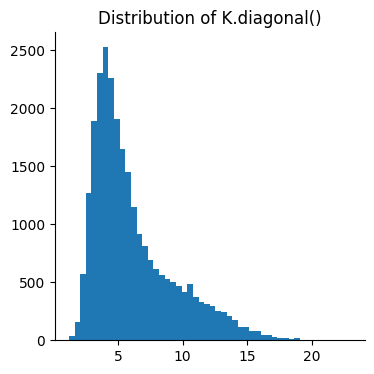

Min/Max/Mean of K.diagonal(): 1.2046092531722299, 23.018296810474205, 6.161469505633124
Number of zero K.diagonal() entries: 0


In [31]:
K = M @ M.T
K_diag = K.diagonal()
plt.hist(K_diag, bins=50)
plt.title("Distribution of K.diagonal()")
plt.show()
print(f"Min/Max/Mean of K.diagonal(): {np.min(K_diag)}, {np.max(K_diag)}, {np.mean(K_diag)}")
print(f"Number of zero K.diagonal() entries: {np.sum(K_diag == 0)}")

In [34]:
M

<25932x25932 sparse matrix of type '<class 'numpy.float64'>'
	with 6199502 stored elements in Compressed Sparse Row format>

In [ ]:
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigs

def diffuse_matrix(M, t=1):
    """
    Apply diffusion to similarity matrix M (e.g., SNN matrix).
    
    Parameters:
        M: (n x n) similarity matrix (dense or sparse)
        t: diffusion time (int), controls the amount of smoothing

    Returns:
        D_t: Diffused matrix
    """
    # Step 1: Row-normalize M to get transition probabilities
    row_sums = np.array(M.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1  # avoid division by zero
    P = M / row_sums[:, np.newaxis]

    # Convert sparse matrix to dense for matrix power operation
    P_dense = P.toarray() if sparse.issparse(P) else P

    # Step 2: Raise to power t for diffusion
    # P^t gives transition probabilities after t steps
    D_t = np.linalg.matrix_power(P_dense, t)
    return D_t

diffused_matrix = diffuse_matrix(snn_after_average, t=1)
print(diffused_matrix)

[[0.04230706 0.         0.         ... 0.         0.         0.        ]
 [0.         0.04067572 0.         ... 0.         0.         0.        ]
 [0.         0.         0.03158148 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.02614289 0.         0.        ]
 [0.         0.         0.         ... 0.         0.03324546 0.        ]
 [0.         0.         0.         ... 0.         0.         0.04012519]]


In [40]:
diffused_matrix.shape

(25932, 25932)

In [55]:
from scipy.sparse import diags

def laplacian_diffusion(M, alpha=0.5):
    """Applies Laplacian diffusion smoothing to similarity matrix M."""
    D = np.array(M.sum(axis=1)).flatten()
    D_inv = diags(1.0 / D)
    I = np.eye(M.shape[0])  # Identity matrix
    L_rw = I - D_inv.dot(M)  # Random walk normalized Laplacian
    S = np.eye(M.shape[0]) - alpha * D_inv.dot(L_rw)
    return S

#usage
laplacian_matrix = laplacian_diffusion(snn_after_average, alpha=0.5)
print(laplacian_matrix)

[[0.97974141 0.         0.         ... 0.         0.         0.        ]
 [0.         0.9804894  0.         ... 0.         0.         0.        ]
 [0.         0.         0.98470795 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.98727028 0.         0.        ]
 [0.         0.         0.         ... 0.         0.9839299  0.        ]
 [0.         0.         0.         ... 0.         0.         0.98074242]]


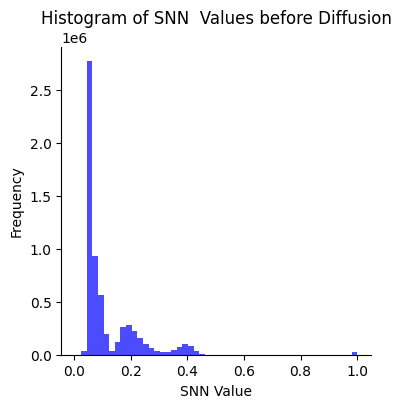

In [51]:
plt.hist(snn_after_average.data, bins=50, color='blue', alpha=0.7)
plt.title("Histogram of SNN  Values before Diffusion")
plt.xlabel("SNN Value")
plt.ylabel("Frequency")
plt.show()

In [41]:
snn_after_average.shape

(25932, 25932)

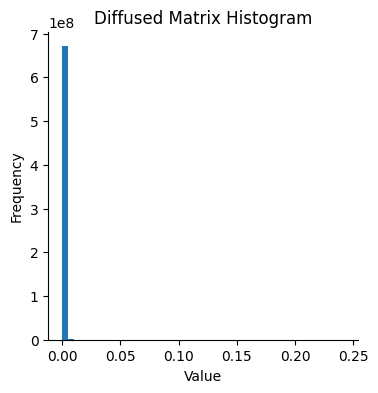

In [45]:
#plot diffused matrix histogram values
plt.hist(diffused_matrix.flatten(), bins=50)
plt.title("Diffused Matrix Histogram")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

In [59]:
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix
import numpy as np

def diffusion_kernel(M, t=1.0, topk=30):
    """
    Apply Gaussian diffusion kernel to a sparse SNN matrix.
    
    Params:
        M: sparse (n x n) CSR matrix (e.g. kNN/SNN)
        t: float, diffusion time (controls smoothing)
        topk: int, number of neighbors to retain per row
    
    Returns:
        D: smoothed and sparsified SNN matrix
    """
    # Symmetrize
    M_sym = 0.5 * (M + M.T)

    # Normalize rows to get transition matrix
    P = normalize(M_sym, norm='l1', axis=1)

    # Exponentiate: Gaussian kernel / diffusion
    D = P.copy()
    for _ in range(int(t) - 1):
        D = D.dot(P)

    # Optional: apply Gaussian-like decay to values
    D.data = np.exp(-1.0 * (1 - D.data))  # Or some other decay function

    # Sparsify: keep topk values per row
    D = topk_filter(D, k=topk)

    # Add self-loops (diagonal = 1.0)
    D.setdiag(1.0)

    return D

def topk_filter(matrix, k):
    """Keep only top-k entries per row in a sparse matrix."""
    from scipy.sparse import lil_matrix
    filtered = lil_matrix(matrix.shape)
    for i in range(matrix.shape[0]):
        row = matrix.getrow(i)
        if row.nnz > k:
            top_indices = row.data.argsort()[-k:]
            filtered_rows = row.indices[top_indices]
            filtered_data = row.data[top_indices]
            filtered[i, filtered_rows] = filtered_data
        else:
            filtered[i, row.indices] = row.data
    return filtered.tocsr()
# Example usage
diffused_matrix = diffusion_kernel(snn_after_average, t=1.0, topk=30)
print(diffused_matrix)

  (0, 0)	1.0
  (0, 241)	0.3714328305363784
  (0, 585)	0.37130417658685316
  (0, 1149)	0.3713569406150417
  (0, 1821)	0.3719193211295844
  (0, 2330)	0.371298386917251
  (0, 3459)	0.37136776730338833
  (0, 3611)	0.3713281601791257
  (0, 5095)	0.3712841343310354
  (0, 5524)	0.37222177563503095
  (0, 5605)	0.3718126558214559
  (0, 5639)	0.37133123853208966
  (0, 5713)	0.37152714213840576
  (0, 5759)	0.3717520328000785
  (0, 5873)	0.37143064161235473
  (0, 6421)	0.3712236159718634
  (0, 7112)	0.37201442137569823
  (0, 7844)	0.3713469956510773
  (0, 8550)	0.3713636138164443
  (0, 9409)	0.3721057766155801
  (0, 9752)	0.37165033966601807
  (0, 10071)	0.3719624782215186
  (0, 10579)	0.3725075016416301
  (0, 10849)	0.3715289123755327
  (0, 12528)	0.37137512036045306
  :	:
  (25931, 19452)	0.3735077737270237
  (25931, 19490)	0.37338256535918574
  (25931, 19567)	0.37382809349573437
  (25931, 19816)	0.37354591597014075
  (25931, 20071)	0.37350474500891523
  (25931, 20084)	0.3737495237104609
  (2593

In [62]:
from sklearn.preprocessing import normalize

# Before diffusion
sim_matrix = normalize(snn_after_average, norm='l1', axis=1)
print("Before diffusion:")
print(sim_matrix)


Before diffusion:
  (0, 0)	0.042307061619054204
  (0, 18)	0.004191215498351589
  (0, 60)	0.004088180834706658
  (0, 73)	0.00890076084962236
  (0, 142)	0.0037064724480393996
  (0, 194)	0.008791385377917195
  (0, 206)	0.003992500386256268
  (0, 241)	0.009612762735090447
  (0, 400)	0.004091098753786674
  (0, 436)	0.004205964591110909
  (0, 511)	0.004012704225659173
  (0, 521)	0.004755343473436997
  (0, 557)	0.004314644074339389
  (0, 583)	0.004131443390158004
  (0, 585)	0.009266330688274309
  (0, 597)	0.0044236211178586265
  (0, 631)	0.004260811509110559
  (0, 671)	0.00424842934455388
  (0, 753)	0.0041670481810927775
  (0, 805)	0.0041913062794572435
  (0, 854)	0.003846825080776161
  (0, 1084)	0.00894235372619644
  (0, 1097)	0.005002678171853801
  (0, 1139)	0.004210485048875466
  (0, 1149)	0.009408425183475818
  :	:
  (25931, 24445)	0.0022832201860638027
  (25931, 24542)	0.014975919621826662
  (25931, 24591)	0.013567272562265881
  (25931, 24753)	0.002278791302808542
  (25931, 24786)	0.0021

In [64]:
diffused_matrix = normalize(diffused_matrix, norm='l1', axis=1)
print("After diffusion:")
print(diffused_matrix)

After diffusion:
  (0, 0)	0.08491457249049486
  (0, 241)	0.031540060013931
  (0, 585)	0.03152913541880785
  (0, 1149)	0.03153361585370435
  (0, 1821)	0.03158137015467374
  (0, 2330)	0.03152864379148872
  (0, 3459)	0.0315345351973168
  (0, 3611)	0.031531171975292455
  (0, 5095)	0.03152743353922334
  (0, 5524)	0.03160705294970155
  (0, 5605)	0.03157231271563443
  (0, 5639)	0.03153143337231837
  (0, 5713)	0.03154806844329804
  (0, 5759)	0.03156716493769109
  (0, 5873)	0.031539874142383316
  (0, 6421)	0.031522294648626416
  (0, 7112)	0.031589445551416226
  (0, 7844)	0.031532771381340884
  (0, 8550)	0.0315341825057486
  (0, 9409)	0.031597202942555566
  (0, 9752)	0.03155852970868713
  (0, 10071)	0.03158503482068526
  (0, 10579)	0.03163131525140133
  (0, 10849)	0.03154821876222689
  (0, 12528)	0.03153515957901395
  :	:
  (25931, 19452)	0.03156211485226493
  (25931, 19490)	0.031551534507854063
  (25931, 19567)	0.031589182479877104
  (25931, 19816)	0.03156533794410575
  (25931, 20071)	0.0315618

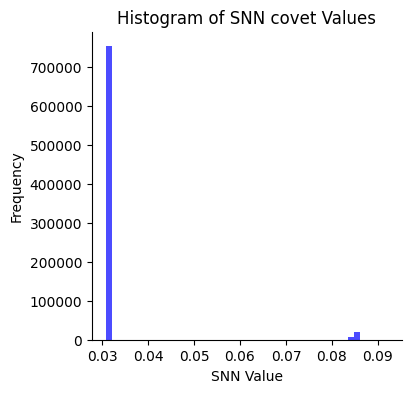

In [65]:
plt.hist(diffused_matrix.data, bins=50, color='blue', alpha=0.7)
plt.title("Histogram of SNN covet Values")
plt.xlabel("SNN Value")
plt.ylabel("Frequency")
plt.show()

In [21]:
model.initialize_archetypes()

Building kernel on X_pca
Computing diffusion components from X_pca for waypoint initialization ... 
Done.
Sampling waypoints ...
Done.
Selecting 99 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 11/11 [00:06<00:00,  1.65it/s]

Selecting 1 cells from greedy initialization.


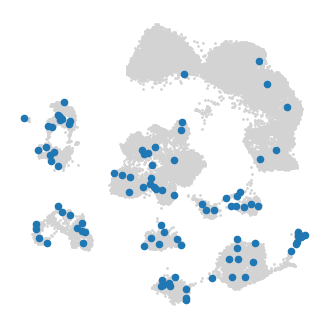

In [23]:
SEACells.plot.plot_initialization(adata, model)

In [24]:
model.fit(min_iter=10, max_iter=50)
print (f'Ran for {len(model.RSS_iters)} iterations')

Randomly initialized A matrix.
  DEBUG: _updateA norms: kernel_matrix=4.00e+02, P=3.19e+02, PtP=7.31e+01, PtM=3.19e+02
 _updateA iter 1: Grad norm: 6.83e+02
 _updateA iter 2: Grad norm: 2.04e+03
 _updateA iter 3: Grad norm: 1.99e+03
 _updateA iter 4: Grad norm: 1.60e+03
 _updateA iter 5: Grad norm: 1.38e+03
 _updateA iter 6: Grad norm: 1.21e+03
 _updateA iter 7: Grad norm: 1.10e+03
 _updateA iter 8: Grad norm: 1.00e+03
 _updateA iter 9: Grad norm: 9.28e+02
 _updateA iter 10: Grad norm: 8.70e+02
 _updateA iter 11: Grad norm: 8.16e+02
 _updateA iter 12: Grad norm: 7.70e+02
 _updateA iter 13: Grad norm: 7.31e+02
 _updateA iter 14: Grad norm: 6.94e+02
 _updateA iter 15: Grad norm: 6.65e+02
 _updateA iter 16: Grad norm: 6.37e+02
 _updateA iter 17: Grad norm: 6.11e+02
 _updateA iter 18: Grad norm: 5.89e+02
 _updateA iter 19: Grad norm: 5.69e+02
 _updateA iter 20: Grad norm: 5.49e+02
 _updateA iter 21: Grad norm: 5.32e+02
 _updateA iter 22: Grad norm: 5.16e+02
 _updateA iter 23: Grad norm: 5.

KeyboardInterrupt: 

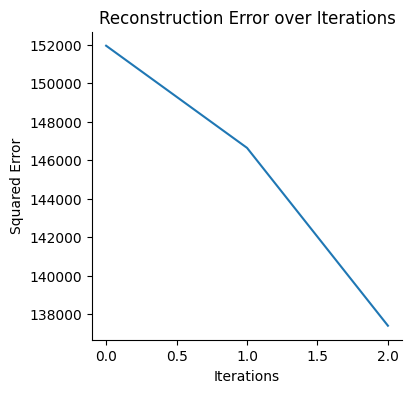

In [25]:
model.plot_convergence()

/Users/anushka/Documents/Undergraduate-Project/SEACells_updated/SEACells/plot.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby("SEACell").mean().reset_index()
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


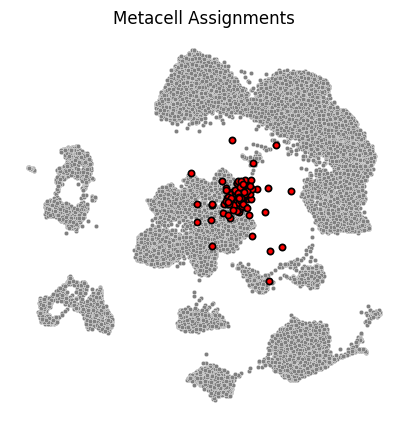

In [27]:
SEACells.plot.plot_2D(adata, colour_metacells=False)

/Users/anushka/Documents/Undergraduate-Project/SEACells_updated/SEACells/plot.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby("SEACell").mean().reset_index()
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


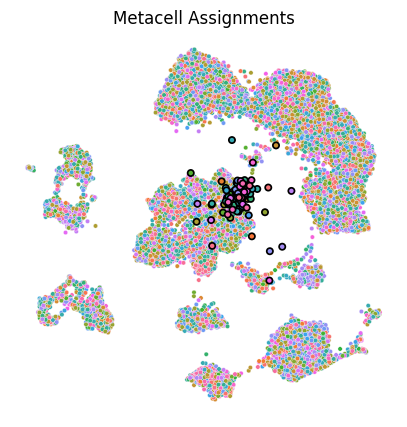

In [29]:
SEACells.plot.plot_2D(adata, colour_metacells=True)